This script only runs from within Meteowiss, because of the data store. It compiles raw data files stored on MeteoSwiss disk into parquet files. 
Incoming raw data files are first organized into folders, and a stastic is computed and displayed showing the number of recently incoming files.
Then, yearly files are generated for Meteo bulletins, Thermo zip files, NOAA CPD2 tarballs. Monthly files are generated for AE33 zip files, G2401 tarballs.

joerg.klausen@meteoswiss.ch

[TODO] Improve handling of erroneous files from g2401.compile_g2401_to_parquet

In [1]:
import os

import pandas as pd
import polars as pl

import housekeeping.organize_files as hk
import monitoring.file_coverage as fc
from processing.ae33 import AE33
from processing.cpd2 import CPD2
from processing.dobson import DData
from processing.g2401 import G2401
from processing.meteo import Meteo
from processing.ne300 import NE300
from processing.thermo import Thermo
from toolbox.utils import load_config, setup_logging

# relative path of level1 data .parquet files on repo
level1 = os.path.join("data", "level1")
os.makedirs(level1, exist_ok=True)

Finished organizing files under '/product_data/data/pay/Kenya/MKN/incoming/ae33/data'. 229 files moved.
Finished organizing files under '/product_data/data/pay/Kenya/MKN/incoming/meteo'. 229 files moved.
Finished organizing files under '/product_data/data/pay/Kenya/MKN/incoming/tei49c'. 38 files moved.
Finished organizing files under '/product_data/data/pay/Kenya/MKN/incoming/tei49i'. 38 files moved.
Finished organizing files under '/product_data/data/pay/Kenya/MKN/incoming/g2401'. 38 files moved.
Finished organizing files under '/product_data/data/pay/Kenya/MKN/incoming/ne300'. 0 files moved.


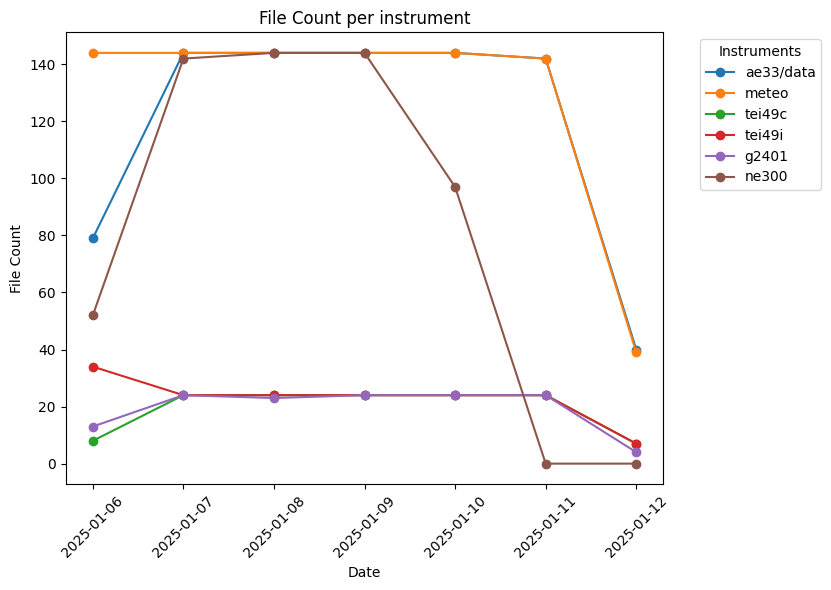

In [2]:
##############################
# Process MKN incoming files #
##############################
# read configuration
mkn = load_config(config_file="mch-mkn.yml")

# setup logging
logger = setup_logging(os.path.join(os.getcwd(), mkn['logging']))

# organize MKN files on MeteoSwiss fileshare
n = hk.organize_files(mkn, branch=mkn['branches']["incoming"], verbosity=1)

# show and plot file statistics
days = 7
stats = fc.get_file_coverage(cfg=mkn, days=days)
fc.plot_file_coverage(stats=stats)

In [3]:
for k, v in mkn['branches'].items():
    if not os.path.exists(os.path.join(mkn['root'], v)):
        raise ValueError(f"path '{v}' not found.")

# path of source files
incoming = os.path.join(mkn['root'], mkn['branches']['incoming'])

# path of archive for successfully processed raw data files.
archive = os.path.join(mkn['root'], mkn['branches']['archive'])

# path for raw data files with issues
issues = os.path.join(mkn['root'], mkn['branches']['issues'])

# path for log files
logs = os.path.join(mkn['root'], mkn['branches']['logs'])

# process all raw data types
years = [f"{year}" for year in range(2023, 2026)]
months = ["{:02d}".format(mm) for mm in range(1, 13, 1)]

met = Meteo(log=os.path.join(logs, "meteo.log"))
for year in years:
    met.compile_vrxa00_to_parquet(
        source=os.path.join(incoming, "meteo", year), 
        target=os.path.join(level1, year), 
        archive=os.path.join(archive, "meteo", year), 
        issues=os.path.join(issues, "meteo"),
        )

Processing source /product_data/data/pay/Kenya/MKN/incoming/meteo/2023 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/meteo/2024 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/meteo/2025 ...
> Processing VRXA00.202501112300 ...
> Processing VRXA00.202501112310 ...
> Processing VRXA00.202501112320 ...
> Processing VRXA00.202501112330 ...
> Processing VRXA00.202501112200 ...
> Processing VRXA00.202501112210 ...
> Processing VRXA00.202501112220 ...
> Processing VRXA00.202501112230 ...
> Processing VRXA00.202501112240 ...
> Processing VRXA00.202501112250 ...
> Processing VRXA00.202501112100 ...
> Processing VRXA00.202501112110 ...
> Processing VRXA00.202501112120 ...
> Processing VRXA00.202501112130 ...
> Processing VRXA00.202501112140 ...
> Processing VRXA00.202501112150 ...
> Processing VRXA00.202501112000 ...
> Processing VRXA00.202501112010 ...
> Processing VRXA00.202501112020 ...
> Processing VRXA00.202501112030 ...
> Processing VRXA00.202501112040 ..

In [4]:
# thermo = Thermo(log=os.path.join(logs, "thermo.log"))
thermo = Thermo(config=mkn)
for year in years:
    thermo.compile_thermo_to_parquet(
        source=os.path.join(incoming, "tei49c", year),
        target=os.path.join(level1, year),
        archive=os.path.join(archive, "tei49c", year),
        issues=os.path.join(issues, "tei49c"),
        )        

2025-01-12T09:51:17, INFO, mch-mkn.processing.thermo, Class 'Thermo' initialized successfully.
2025-01-12T09:51:17, INFO, mch-mkn.processing.thermo, processing source /product_data/data/pay/Kenya/MKN/incoming/tei49c/2023 ...
2025-01-12T09:51:17, INFO, mch-mkn.processing.thermo, processing source /product_data/data/pay/Kenya/MKN/incoming/tei49c/2024 ...
2025-01-12T09:51:17, INFO, mch-mkn.processing.thermo, processing source /product_data/data/pay/Kenya/MKN/incoming/tei49c/2025 ...
2025-01-12T09:51:17, INFO, mch-mkn.processing.thermo, processing tei49c-202501102300.zip ...
2025-01-12T09:51:17, INFO, mch-mkn.processing.thermo, Extracting file /product_data/data/pay/Kenya/MKN/incoming/tei49c/2025/01/10/tei49c-202501102300.zip.
2025-01-12T09:51:17, WARNING, mch-mkn.processing.thermo, /product_data/data/pay/Kenya/MKN/incoming/tei49c/2025/01/10/tei49c-202501102300.zip contains invalid record: 2025-01-10 22:01:33 o3 2339E-2 ppb
2025-01-12T09:51:17, WARNING, mch-mkn.processing.thermo, /product_

In [5]:
for year in years:
    thermo.compile_thermo_to_parquet(
        source=os.path.join(incoming, "tei49i", year),
        target=os.path.join(level1, year),
        archive=os.path.join(archive, "tei49i", year),
        issues=os.path.join(issues, "tei49i"),
        )


2025-01-12T09:51:21, INFO, mch-mkn.processing.thermo, processing source /product_data/data/pay/Kenya/MKN/incoming/tei49i/2023 ...
2025-01-12T09:51:21, INFO, mch-mkn.processing.thermo, processing source /product_data/data/pay/Kenya/MKN/incoming/tei49i/2024 ...
2025-01-12T09:51:21, INFO, mch-mkn.processing.thermo, processing source /product_data/data/pay/Kenya/MKN/incoming/tei49i/2025 ...
2025-01-12T09:51:21, INFO, mch-mkn.processing.thermo, processing tei49i-202501102300.zip ...
2025-01-12T09:51:21, INFO, mch-mkn.processing.thermo, Extracting file /product_data/data/pay/Kenya/MKN/incoming/tei49i/2025/01/10/tei49i-202501102300.zip.
2025-01-12T09:51:21, INFO, mch-mkn.processing.thermo, archive: /product_data/data/pay/Kenya/MKN/incoming/tei49i/2025/01/10/tei49i-202501102300.zip > /product_data/data/pay/Kenya/MKN/archive/tei49i/2025/01/10
2025-01-12T09:51:21, INFO, mch-mkn.processing.thermo, processing tei49i-202501102200.zip ...
2025-01-12T09:51:21, INFO, mch-mkn.processing.thermo, Extract

Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/01 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/02 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/03 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/04 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/05 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/06 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/07 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/08 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/09 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/10 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/11 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2023/12 ...
Processing sourc

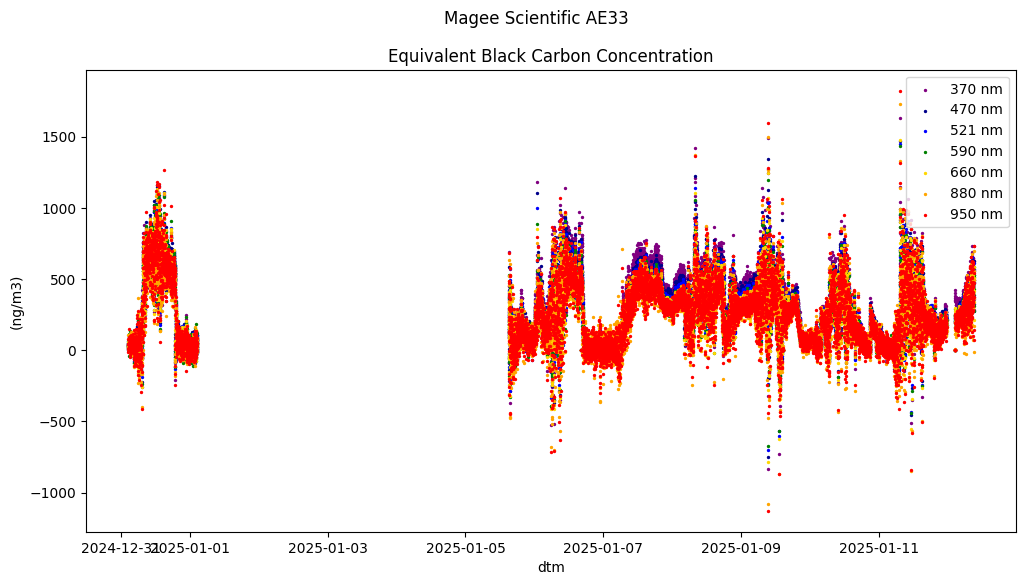

Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2025/02 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2025/03 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2025/04 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2025/05 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2025/06 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2025/07 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2025/08 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2025/09 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2025/10 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2025/11 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/ae33/data/2025/12 ...


In [6]:
ae33 = AE33(log=os.path.join(logs, "ae33.log"))
for year in years:
    for month in months:
        ae33.zipfiles_to_parquet(
            source=os.path.join(incoming, "ae33", "data", year, month), 
            target=os.path.join(level1, year, month), 
            archive=os.path.join(archive, "ae33", "data", year, month), 
            issues=os.path.join(issues, "ae33"), 
            plot=True,
            )

In [7]:
g2401 = G2401(log=os.path.join(logs, "g2401.log"))
for year in years:
    for month in months:
        g2401.compile_g2401_to_parquet(
            source=os.path.join(incoming, "g2401", year, month), 
            target=os.path.join(level1, year, month), 
            archive=os.path.join(archive, "g2401", year, month), 
            issues=os.path.join(issues, "g2401", year),
            )

Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2023/01 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2023/02 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2023/03 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2023/04 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2023/05 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2023/06 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2023/07 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2023/08 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2023/09 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2023/10 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2023/11 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g2401/2023/12 ...
Processing source /product_data/data/pay/Kenya/MKN/incoming/g240

In [8]:
ne300 = NE300(config=mkn)
for year in years:
    for month in months:
        ne300.compile_files_to_parquet(
            source=os.path.join(incoming, "ne300", year, month), 
            target=os.path.join(level1, year, month), 
            archive=os.path.join(archive, "ne300", year, month), 
            issues=os.path.join(issues, "ne300", year),
            )            

2025-01-12T09:51:43, INFO, mch-mkn.processing.ne300, Initialize NE300 class.
2025-01-12T09:51:43, ERROR, mch-mkn.processing.ne300, update parquet file: ne300_native.parquet produced error: at least one key is required in a group_by operation


In [9]:
# # read configuration
# mkn = load_config(config_file="mch-mkn.yml")

# ne300 = NE300(config=mkn)

# ne300.compile_files_to_parquet()

In [10]:
# display empty directories under source
# os.system(f"find {source} -empty -type d)

# display empty directories under source (NB: no questions asked!)
# os.system(f"find {source} -empty -type d -delete")

In [11]:
##############################
# Process NRB incoming files #
##############################
# read configuration
nrb = load_config(config_file="mch-nrb.yml")

# setup logging
logger = setup_logging(os.path.join(os.getcwd(), nrb["nrb-dobson"]['logging']))


n = hk.organize_files(nrb["nrb-dobson"], branch="uploads")
print(f"Finished organizing files under '{nrb['nrb-dobson']['root']}'. {n} files moved.")

days = 60
stats = fc.get_file_coverage(cfg=nrb['nrb-dobson'], days=days)
fc.plot_coverage(stats=stats, days=days)
fc.print_coverage(stats=stats, days=days)

ddata = DData(config=nrb['nrb-dobson'])
headers, df_data = ddata.process_directory(os.path.join(nrb['nrb-dobson']["root"], nrb['nrb-dobson']['branches']['uploads']))
df_data.write_parquet(os.path.join(level1, 'd018_nrb_data.parquet'))

df_headers = pl.DataFrame(headers, orient='row')
df_headers.write_parquet(os.path.join(level1, 'd018_nrb_headers.parquet'))

Finished organizing files under '/product_data/data/pay/Kenya'. 0 files moved.


AttributeError: module 'monitoring.file_coverage' has no attribute 'plot_coverage'

In [ ]:
file = 'data/level1/d018_nrb_data.parquet'
df = pl.read_parquet(file)
df = df.with_columns(pl.col('dtm').str.to_datetime(),
                     pl.col('sza').cast(pl.Float32),
                     pl.col('mu').cast(pl.Float32),
                     pl.col('XAD').cast(pl.Float32),
                     pl.col('X1').cast(pl.Float32),
                     pl.col('X2').cast(pl.Float32),
                     pl.col('X3').cast(pl.Float32),
                     pl.col('X4').cast(pl.Float32),
                     pl.col('X5').cast(pl.Float32),)
display(df.describe())

display(df.plot(x='dtm', y='sza'))
display(df.plot(x='dtm', y='mu'))
display(df.plot(x='dtm', y='XAD'))

In [ ]:
# Brewer B071 file statistics
days = 7
stats = fc.get_file_coverage(cfg=nrb["nrb-brewer"], days=days)
fc.plot_coverage(stats=stats, days=days)
fc.print_coverage(stats=stats, days=days)